## Bank Loan Report | End to end KPI and portfolio analysis in Python

This project builds a complete Bank Loan Report in Python to monitor lending performance, portfolio quality, and time based trends. The core goal is to calculate the required KPIs, separate Good Loans vs Bad Loans using loan status rules, and produce the visuals needed for a multi page reporting flow. 

## Project Owner

**Mert Ovet**
**LinkedIn:** https://www.linkedin.com/in/mertovet


### What this analysis delivers
1) **Dashboard 1 | Summary KPIs**
- Total Loan Applications, including Month to Date tracking
- Total Funded Amount, including Month to Date tracking
- Total Amount Received, including Month to Date tracking
- Average Interest Rate
- Average Debt to Income Ratio (DTI) :contentReference[oaicite:2]{index=2}

2) **Good Loans vs Bad Loans performance**
- Good Loans are loans with status **Fully Paid** or **Current**
- Bad Loans are loans with status **Charged Off**
- For each group, the analysis calculates application count, funded amount, received amount, and application share of total volume :contentReference[oaicite:3]{index=3}

3) **Dashboard 2 | Trend and segmentation views**
- Monthly trends based on Issue Date for applications, funded amount, and received amount
- Regional view by state
- Loan term distribution
- Employment length breakdown
- Loan purpose breakdown
- Home ownership breakdown :contentReference[oaicite:4]{index=4}

### Method highlights
- Data is cleaned and standardized before KPI calculations, including robust date parsing for Issue Date so that monthly and MTD logic is accurate.
- KPIs are computed directly from the dataset using pandas aggregations such as `count`, `sum`, and `mean`.
- Visuals are produced using Matplotlib for trend and bar charts, plus Plotly for the treemap.

### Tech stack
- Python
- Pandas
- Matplotlib
- Plotly
- Jupyter Notebook


In [9]:
import sys
!{sys.executable} -m pip install matplotlib seaborn plotly

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 4.2 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.1 MB 4.8 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 4.7 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.1 MB 5.2 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.1 MB 5.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 4.4 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 3.9 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 3.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 3.4 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 3.2 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 3.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 3.0 MB/s eta 0:00:01
   ----------------

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [49]:
df = pd.read_csv("financial_loan.csv")

In [50]:
type(pd)
df.shape
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


### Metadata of Data

In [51]:
print("No of Rows:", df.shape[0])

No of Rows: 38576


In [52]:
print("No of Colums:", df.shape[1])

No of Colums: 24


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade              38576 non-null  object 
 15  te

### Data Types ###

In [54]:
df.dtypes

id                         int64
address_state             object
application_type          object
emp_length                object
emp_title                 object
grade                     object
home_ownership            object
issue_date                object
last_credit_pull_date     object
last_payment_date         object
loan_status               object
next_payment_date         object
member_id                  int64
purpose                   object
sub_grade                 object
term                      object
verification_status       object
annual_income            float64
dti                      float64
installment              float64
int_rate                 float64
loan_amount                int64
total_acc                  int64
total_payment              int64
dtype: object

In [55]:
df.describe()

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


### Total Loan Applications ###

In [56]:
total_loan_application=df['id'].count()
print ("Total Loan Applications:", total_loan_application)

Total Loan Applications: 38576


### MTD Total Loan Applications ###

In [57]:
# 1) read data
df = pd.read_csv("financial_loan.csv")

# 2)Try parsing the date using two formats and choose the one that produces fewer NaT values.
s = df["issue_date"].astype(str).str.strip()

dt_dmy = pd.to_datetime(s, format="%d-%m-%Y", errors="coerce")
dt_mdy = pd.to_datetime(s, format="%m-%d-%Y", errors="coerce")

if dt_dmy.notna().sum() >= dt_mdy.notna().sum():
    df["issue_date"] = dt_dmy
    chosen = "DMY (%d-%m-%Y)"
else:
    df["issue_date"] = dt_mdy
    chosen = "MDY (%m-%d-%Y)"

# 3) Sanity check (did NaT values blow up?)
parsed = df["issue_date"].notna().sum()
total = len(df)
print("Chosen format:", chosen)
print(f"Parsed dates: {parsed}/{total}  |  NaT: {total-parsed}")

# 4) MTD calculation (latest month)
latest_issue_date = df["issue_date"].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df["issue_date"].dt.year == latest_year) & (df["issue_date"].dt.month == latest_month)]
mtd_loan_applications = mtd_data["id"].count()

print(f"MTD Loan Applications (for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")

Chosen format: DMY (%d-%m-%Y)
Parsed dates: 38576/38576  |  NaT: 0
MTD Loan Applications (for December 2021): 4314


### Total Funded Amount ###

In [59]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount / 1000000
print("Total Funded Amount: ${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount: $435.76M


### MTD- Total Funded Amount ###

In [64]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[
    (df['issue_date'].dt.year == latest_year) &
    (df['issue_date'].dt.month == latest_month)
]

mtd_total_amount_received = mtd_data['total_payment'].sum()
mtd_total_amount_received_millions = mtd_total_amount_received / 1000000

print("MTD Total Amount received: ${:.2f}M".format(mtd_total_amount_received_millions))

MTD Total Amount received: $58.07M


### Average Interest Rate ###

In [65]:
average_interest_rate = df['int_rate'].mean() * 100
print("Avg Int Rate:{:.2f}%".format(average_interest_rate))

Avg Int Rate:12.05%


### Average Debt-to-Income Ratio (DTI) ###

In [66]:
average_dti = df['dti'].mean() * 100
print("Avg DTI:{:.2f}%".format(average_dti))

Avg DTI:13.33%


### Good Loan Metrics ###

In [67]:
good_loans = df[df['loan_status'].isin(["Fully Paid", "Current"])]

total_loan_applications = df['id'].count()

good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000
good_loan_received_millions = good_loan_received / 1000000

good_loan_percentage = (good_loan_applications / total_loan_applications) * 100

print("Good Loan Applications:", good_loan_applications)
print("Good Loan Funded Amount (in Millions): ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Total Received (in Millions): ${:.2f}M".format(good_loan_received_millions))
print("Percentage of Good Loan Applications: {:.2f}%".format(good_loan_percentage))


Good Loan Applications: 33243
Good Loan Funded Amount (in Millions): $370.22M
Good Loan Total Received (in Millions): $435.79M
Percentage of Good Loan Applications: 86.18%


### Bad Loan Metrics ###

In [69]:
bad_loans = df[df['loan_status'].isin(["Charged Off"])]

total_loan_applications = df['id'].count()

bad_loan_applications = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_received = bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount / 1000000
bad_loan_received_millions = bad_loan_received / 1000000

bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100

print("Bad Loan Applications:", bad_loan_applications)
print("Bad Loan Funded Amount (in Millions): ${:.2f}M".format(bad_loan_funded_amount_millions))
print("Bad Loan Total Received (in Millions): ${:.2f}M".format(bad_loan_received_millions))
print("Percentage of Bad Loan Applications: {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications: 5333
Bad Loan Funded Amount (in Millions): $65.53M
Bad Loan Total Received (in Millions): $37.28M
Percentage of Bad Loan Applications: 13.82%


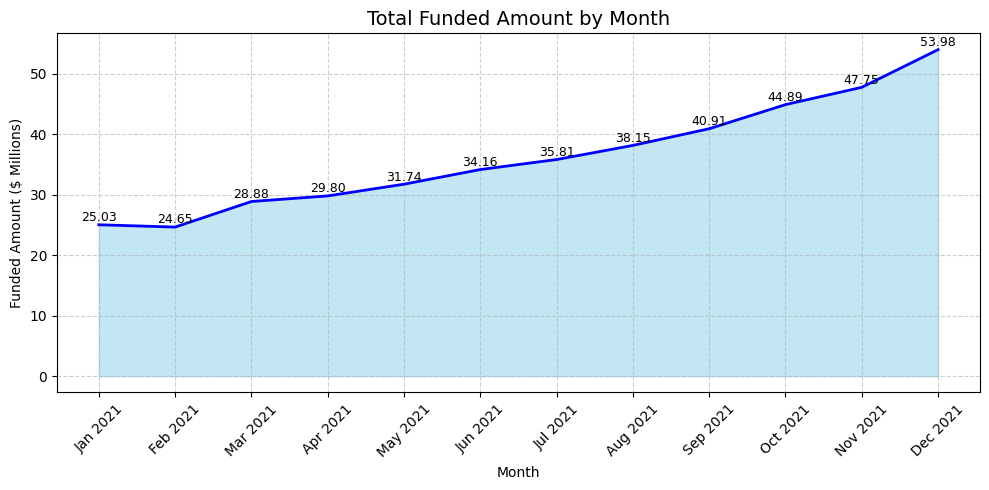

In [88]:
monthly_funded = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['loan_amount']
      .sum()
      .div(1_000_000)
      .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='skyblue',
    alpha=0.5
)
plt.plot(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='blue',
    linewidth=2
)

for i, row in monthly_funded.iterrows():
    plt.text(
        i,
        row['loan_amount_millions'] + 0.1,
        f"{row['loan_amount_millions']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount ($ Millions)')
plt.xticks(
    ticks=range(len(monthly_funded)),
    labels=monthly_funded['month_name'],
    rotation=45
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends by Issue Date for Total Amount Received ###

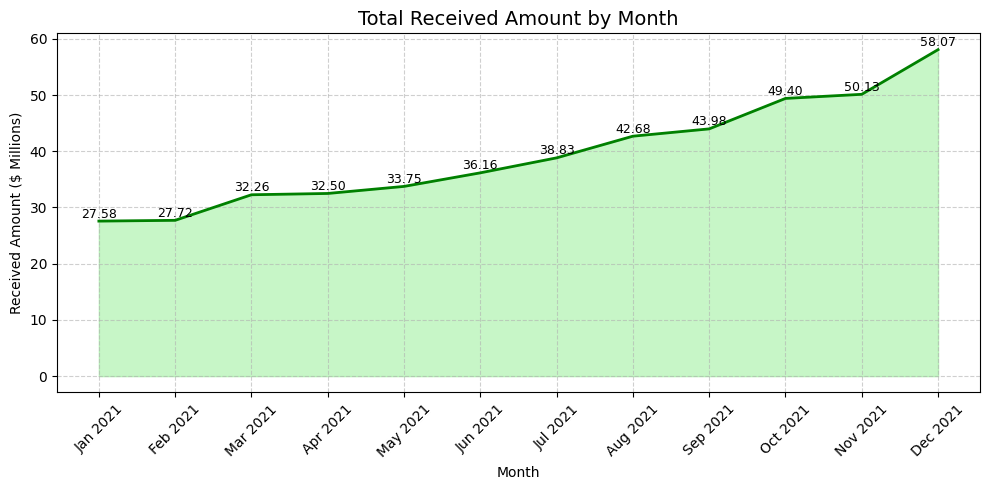

In [87]:
monthly_received = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['total_payment']
      .sum()
      .div(1_000_000)
      .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between(
    monthly_received['month_name'],
    monthly_received['received_amount_millions'],
    color='lightgreen',
    alpha=0.5
)
plt.plot(
    monthly_received['month_name'],
    monthly_received['received_amount_millions'],
    color='green',
    linewidth=2
)

for i, row in monthly_received.iterrows():
    plt.text(
        i,
        row['received_amount_millions'] + 0.1,
        f"{row['received_amount_millions']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )

plt.title('Total Received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount ($ Millions)')
plt.xticks(
    ticks=range(len(monthly_received)),
    labels=monthly_received['month_name'],
    rotation=45
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Monthly Trends by Issue Date for Total loan Application ###

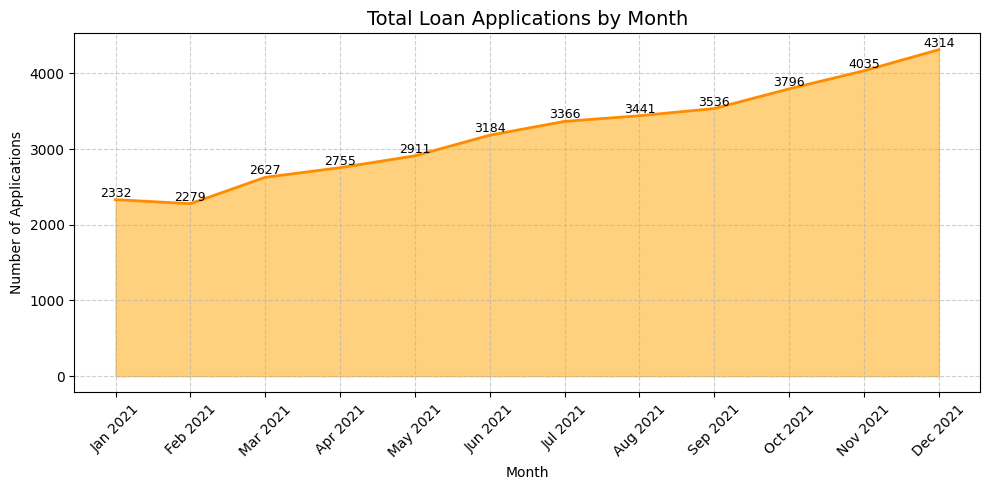

In [74]:
monthly_applications = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['id']
      .count()
      .reset_index(name='loan_applications_count')
)

plt.figure(figsize=(10, 5))

plt.fill_between(
    monthly_applications['month_name'],
    monthly_applications['loan_applications_count'],
    color='orange',
    alpha=0.5
)

plt.plot(
    monthly_applications['month_name'],
    monthly_applications['loan_applications_count'],
    color='darkorange',
    linewidth=2
)

for i, row in monthly_applications.iterrows():
    plt.text(
        i,
        row['loan_applications_count'] + 0.5,
        f"{row['loan_applications_count']}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )

plt.title('Total Loan Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')

plt.xticks(
    ticks=range(len(monthly_applications)),
    labels=monthly_applications['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regional Analysis by State  for Total Funded Amount ###

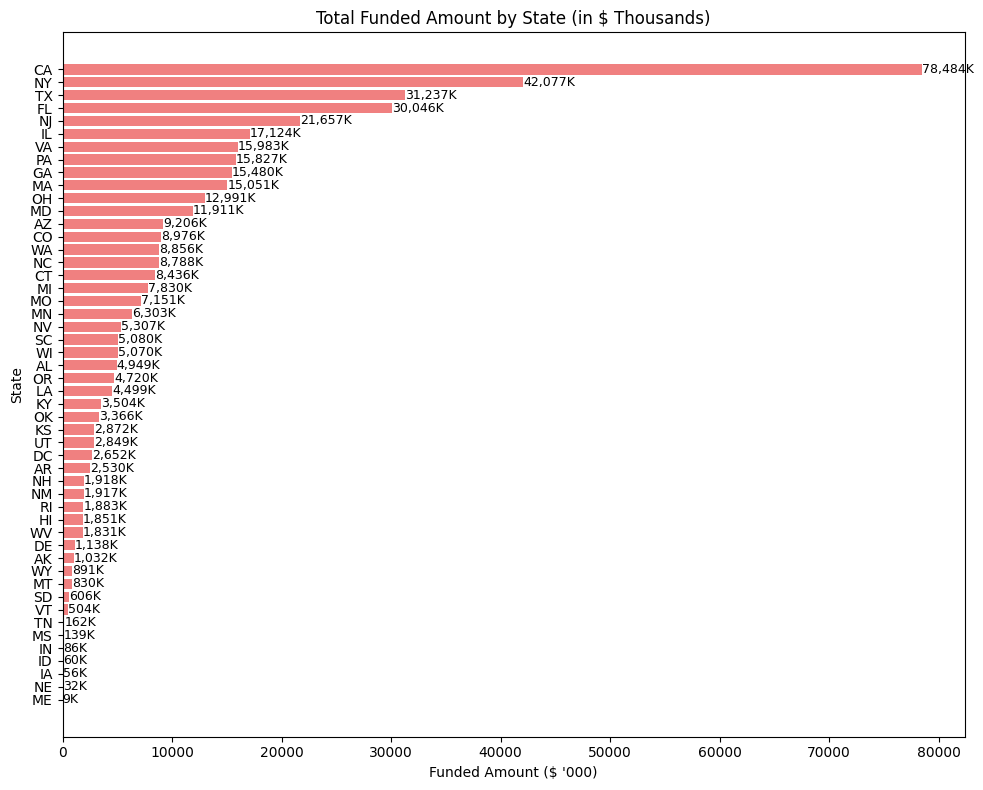

In [86]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(10, 8))
bars = plt.barh(
    state_funding_thousands.index,
    state_funding_thousands.values,
    color='lightcoral'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}K',
        va='center',
        fontsize=9
    )

plt.title('Total Funded Amount by State (in $ Thousands)')
plt.xlabel('Funded Amount ($ \'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Loan Term Analysis by Total Funded Amount ###

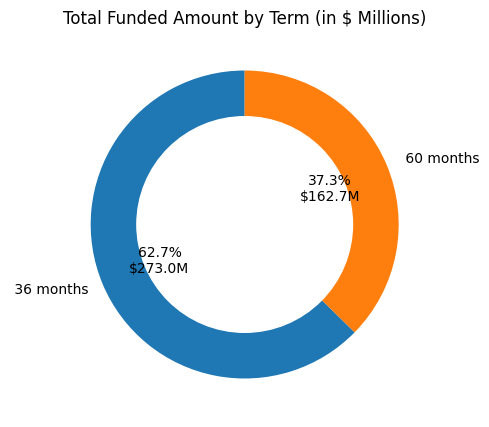

In [79]:
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1_000_000

plt.figure(figsize=(5, 5))
plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p * sum(term_funding_millions) / 100:.1f}M",
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt.title("Total Funded Amount by Term (in $ Millions)")
plt.show()

### Employee Lenght by Total Funded Amount ###

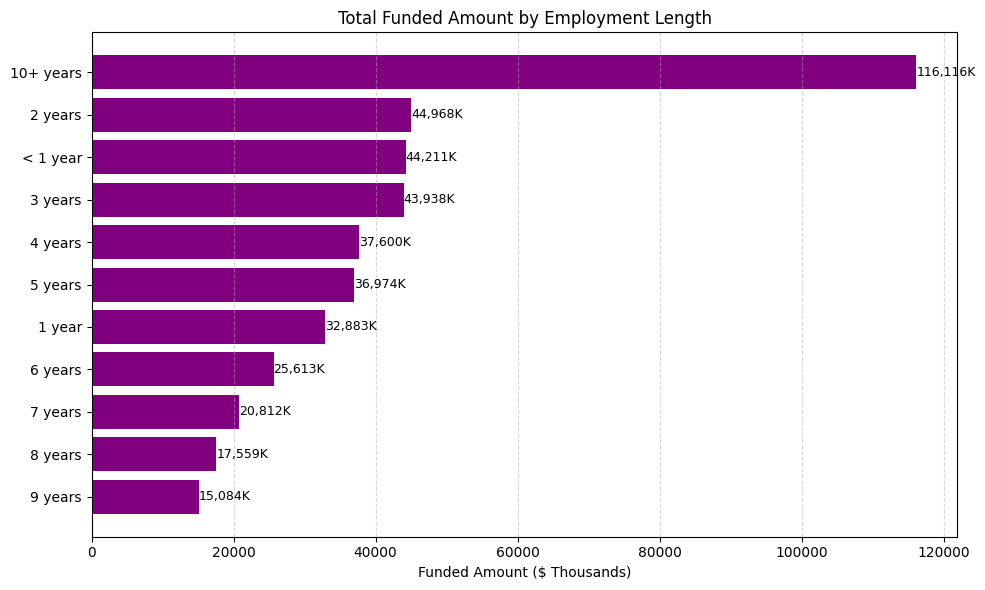

In [84]:
emp_funding = df.groupby('emp_length')['loan_amount'].sum().sort_values() / 1000

plt.figure(figsize=(10, 6))
bars = plt.barh(emp_funding.index, emp_funding, color='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}K",
        va='center',
        fontsize=9
    )

plt.xlabel("Funded Amount ($ Thousands)")
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Loan Purpose by Total Funded Amount ###

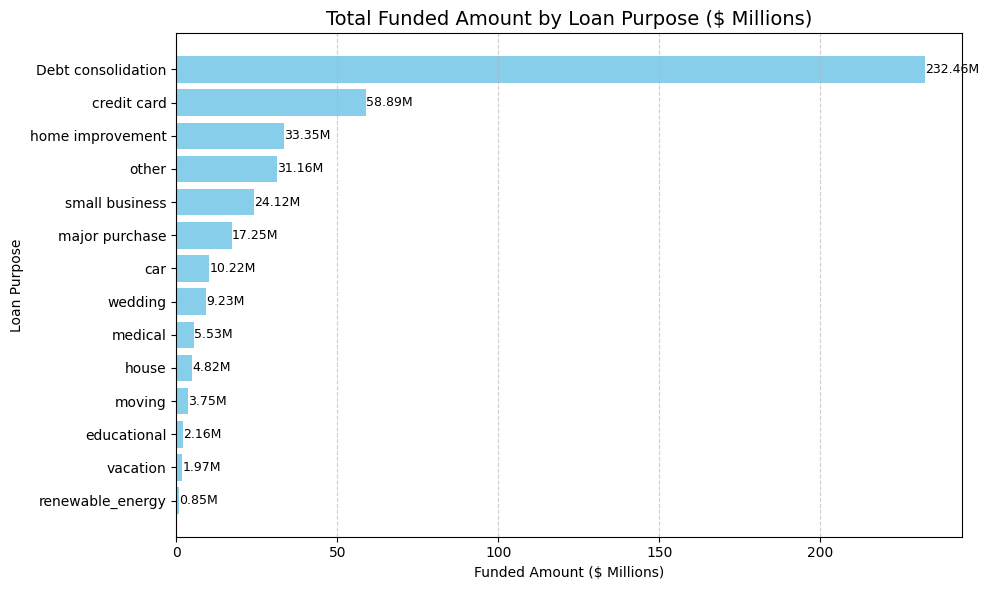

In [83]:
purpose_funding_millions = (
    df.groupby('purpose')['loan_amount']
      .sum()
      .sort_values() / 1_000_000
)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    purpose_funding_millions.index,
    purpose_funding_millions.values,
    color='skyblue'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}M",
        va='center',
        fontsize=9
    )

plt.title("Total Funded Amount by Loan Purpose ($ Millions)", fontsize=14)
plt.xlabel("Funded Amount ($ Millions)")
plt.ylabel("Loan Purpose")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Home Ownership by Total Funded Amount ###

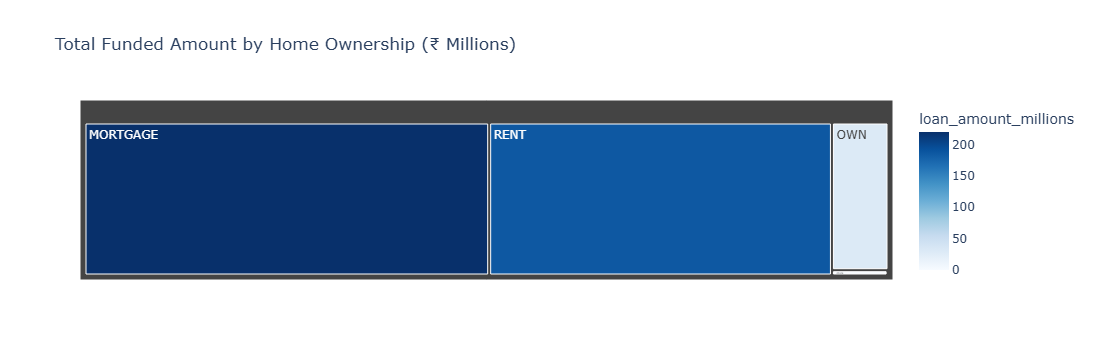

In [89]:
home_funding = (
    df.groupby('home_ownership')['loan_amount']
      .sum()
      .reset_index()
)

home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1_000_000

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blues',
    title='Total Funded Amount by Home Ownership (₹ Millions)'
)

fig.show()